===================== FOIL - LOAN APPROVAL CLASSIFICATION ======================

DATASET
+---------------+----------+---------------+--------+--------------+----------------+
| Employment    | Income   | CreditScore   | Debt   | Collateral   | LoanApproved   |
+===============+==========+===============+========+==============+================+
| Salaried      | High     | Good          | Low    | Yes          | Yes            |
+---------------+----------+---------------+--------+--------------+----------------+
| Salaried      | High     | Average       | Low    | No           | Yes            |
+---------------+----------+---------------+--------+--------------+----------------+
| Salaried      | Medium   | Good          | Low    | Yes          | Yes            |
+---------------+----------+---------------+--------+--------------+----------------+
| Self-employed | High     | Good          | Low    | Yes          | Yes            |
+---------------+----------+---------------+------

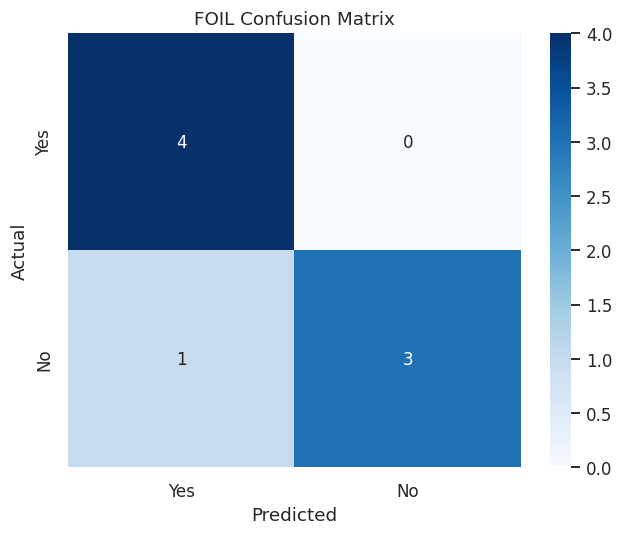

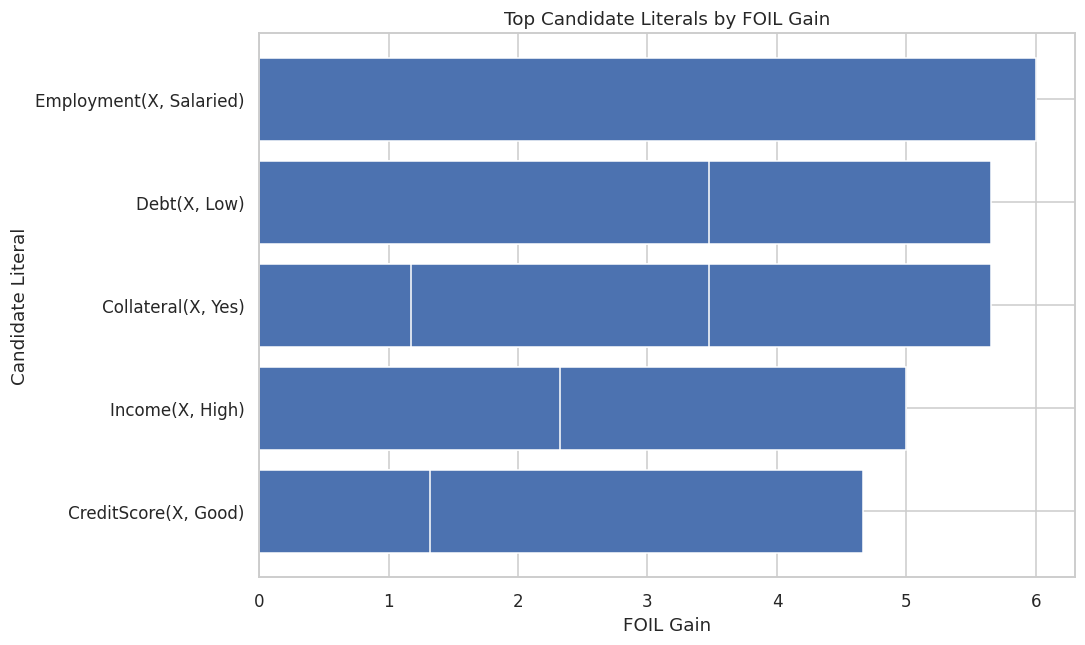


============================== FOIL RULE COVERAGE ==============================
+--------+-----------------------------+-----------------+------------+------------+
| Rule   | Learned Rule                |   Total Covered |   Positive |   Negative |
+========+=============================+=================+============+============+
| R1     | Employment=Salaried         |               6 |          6 |          0 |
+--------+-----------------------------+-----------------+------------+------------+
| R2     | Debt=Low AND Collateral=Yes |               6 |          6 |          0 |
+--------+-----------------------------+-----------------+------------+------------+

================================ FINAL SUMMARY =================================

1. A Loan Approval dataset was created.
2. The dataset was divided into training and testing sets.
3. Training examples were converted into first-order knowledge-base facts.
4. FOIL generated candidate literals.
5. FOIL Gain was calculated 

In [2]:
# ============================================================================
#             FOIL - FIRST ORDER INDUCTIVE LEARNER
#             LOAN APPROVAL DATASET
#             Google Colab / Jupyter Ready
# ============================================================================

# ============================================================================
# SECTION 1 : IMPORT LIBRARIES
# ============================================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11


# ============================================================================
# SECTION 2 : CREATE THE DATASET
# ============================================================================

# Loan Approval Dataset

data = {
    "Employment": [
        "Salaried", "Salaried", "Salaried", "Self-employed",
        "Self-employed", "Self-employed", "Student", "Student",
        "Salaried", "Salaried", "Self-employed", "Student",
        "Salaried", "Self-employed", "Student", "Salaried",
        "Self-employed", "Student", "Salaried", "Self-employed",
        "Student", "Salaried", "Self-employed", "Student"
    ],

    "Income": [
        "High", "High", "Medium", "High",
        "Medium", "Low", "Low", "Medium",
        "Medium", "Low", "High", "Low",
        "High", "Medium", "Low", "Medium",
        "High", "Medium", "High", "Low",
        "Medium", "High", "Medium", "Low"
    ],

    "CreditScore": [
        "Good", "Average", "Good", "Good",
        "Average", "Poor", "Good", "Average",
        "Good", "Poor", "Good", "Poor",
        "Good", "Average", "Poor", "Good",
        "Good", "Average", "Good", "Poor",
        "Average", "Good", "Average", "Poor"
    ],

    "Debt": [
        "Low", "Low", "Low", "Low",
        "High", "High", "Low", "High",
        "High", "High", "Low", "High",
        "Low", "Low", "High", "Low",
        "High", "Low", "Low", "High",
        "High", "Low", "High", "High"
    ],

    "Collateral": [
        "Yes", "No", "Yes", "Yes",
        "Yes", "No", "No", "No",
        "Yes", "No", "Yes", "No",
        "Yes", "Yes", "No", "Yes",
        "No", "Yes", "Yes", "No",
        "No", "Yes", "No", "No"
    ],

    "LoanApproved": [
        "Yes", "Yes", "Yes", "Yes",
        "No", "No", "No", "No",
        "Yes", "No", "Yes", "No",
        "Yes", "Yes", "No", "Yes",
        "No", "Yes", "Yes", "No",
        "No", "Yes", "No", "No"
    ]
}

df = pd.DataFrame(data)


# ============================================================================
# SECTION 3 : DISPLAY DATASET
# ============================================================================

print("=" * 80)
print(" FOIL - LOAN APPROVAL CLASSIFICATION ".center(80, "="))
print("=" * 80)

print("\nDATASET")
print(tabulate(
    df,
    headers="keys",
    tablefmt="grid",
    showindex=False
))

print("\nDataset Shape :", df.shape)

print("\nClass Distribution:")
print(df["LoanApproved"].value_counts())


# ============================================================================
# SECTION 4 : TRAIN / TEST SPLIT
# ============================================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["LoanApproved"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n" + "=" * 80)
print(" TRAIN / TEST SPLIT ".center(80, "="))
print("=" * 80)

print("\nTraining Samples :", len(train_df))
print("Testing Samples  :", len(test_df))

print("\nTRAINING DATA")
print(tabulate(
    train_df,
    headers="keys",
    tablefmt="grid",
    showindex=False
))

print("\nTEST DATA")
print(tabulate(
    test_df,
    headers="keys",
    tablefmt="grid",
    showindex=False
))


# ============================================================================
# SECTION 5 : DEFINE FEATURES AND TARGET
# ============================================================================

FEATURES = [
    "Employment",
    "Income",
    "CreditScore",
    "Debt",
    "Collateral"
]

TARGET = "LoanApproved"

POSITIVE_CLASS = "Yes"
NEGATIVE_CLASS = "No"


# ============================================================================
# SECTION 6 : RULE COVERAGE FUNCTION
# ============================================================================

def rule_covers(row, conditions):

    for feature, value in conditions.items():

        if row[feature] != value:
            return False

    return True


def evaluate_rule(dataframe, conditions):

    mask = pd.Series(
        True,
        index=dataframe.index
    )

    for feature, value in conditions.items():

        mask &= (
            dataframe[feature] == value
        )

    return dataframe[mask]


# ============================================================================
# SECTION 7 : CREATE FIRST-ORDER KNOWLEDGE BASE
# ============================================================================

print("\n" + "=" * 80)
print(" FOIL : FIRST-ORDER KNOWLEDGE BASE ".center(80, "="))
print("=" * 80)

FOIL_FACTS = {}

# Create feature predicates

for feature in FEATURES:

    FOIL_FACTS[feature] = set()


# Add feature facts

for idx, row in train_df.iterrows():

    example_id = f"e{idx + 1}"

    for feature in FEATURES:

        FOIL_FACTS[feature].add(
            (
                example_id,
                row[feature]
            )
        )


# Create target predicate

FOIL_FACTS[TARGET] = set()

for idx, row in train_df.iterrows():

    example_id = f"e{idx + 1}"

    FOIL_FACTS[TARGET].add(
        (
            example_id,
            row[TARGET]
        )
    )


# Display knowledge base

for predicate in FOIL_FACTS:

    print(f"\n{predicate}:")

    for fact in sorted(
        FOIL_FACTS[predicate]
    ):

        print(
            f"  {predicate}{fact}"
        )


# ============================================================================
# SECTION 8 : DISPLAY FIRST-ORDER LITERALS
# ============================================================================

def foil_literal_string(feature, value):

    return f"{feature}(X, {value})"


# ============================================================================
# SECTION 9 : FOIL GAIN
# ============================================================================

def foil_gain(
    p0,
    n0,
    p1,
    n1,
    t
):

    # Invalid candidate

    if (
        p1 == 0
        or p0 == 0
        or t == 0
    ):

        return float("-inf")


    # FOIL Gain formula

    gain = t * (
        math.log2(
            p1 / (p1 + n1)
        )
        -
        math.log2(
            p0 / (p0 + n0)
        )
    )

    return gain


# ============================================================================
# SECTION 10 : GENERATE FOIL CANDIDATES
# ============================================================================

def generate_foil_candidates(
    dataframe,
    current_rule
):

    candidates = []

    for feature in FEATURES:

        # Do not use the same feature twice

        if feature in current_rule:
            continue

        # Get all possible values

        values = sorted(
            dataframe[feature].unique()
        )

        for value in values:

            candidates.append(
                {
                    feature: value
                }
            )

    return candidates


# ============================================================================
# SECTION 11 : LEARN ONE FOIL RULE
# ============================================================================

def foil_learn_one_rule(
    positives,
    negatives
):

    current_rule = {}

    p0 = len(positives)
    n0 = len(negatives)

    trace = []

    print("\nStarting new FOIL rule")

    while n0 > 0:

        candidates = generate_foil_candidates(
            pd.concat(
                [positives, negatives]
            ),
            current_rule
        )

        if not candidates:

            break


        scored_candidates = []


        # Evaluate every candidate literal

        for literal in candidates:

            candidate_rule = (
                current_rule.copy()
            )

            candidate_rule.update(
                literal
            )


            # Positive examples covered

            pos_covered = evaluate_rule(
                positives,
                candidate_rule
            )


            # Negative examples covered

            neg_covered = evaluate_rule(
                negatives,
                candidate_rule
            )


            p1 = len(pos_covered)

            n1 = len(neg_covered)


            # Number of positive examples
            # that remain after adding literal

            t = p1


            # Calculate FOIL Gain

            gain = foil_gain(
                p0,
                n0,
                p1,
                n1,
                t
            )


            feature_name = list(
                literal.keys()
            )[0]

            value_name = list(
                literal.values()
            )[0]


            literal_name = (
                f"{feature_name}(X, {value_name})"
            )


            scored_candidates.append(
                {
                    "literal": literal_name,
                    "conditions": candidate_rule,
                    "p1": p1,
                    "n1": n1,
                    "t": t,
                    "gain": gain
                }
            )


        # Sort by highest FOIL Gain

        scored_candidates.sort(
            key=lambda x: x["gain"],
            reverse=True
        )


        # Select candidate with maximum gain

        best = scored_candidates[0]


        # Store candidate information

        trace.extend(
            scored_candidates
        )


        # If no valid candidate

        if best["gain"] == float("-inf"):

            break


        # Display selected literal

        print(
            "\nSelected Literal :",
            best["literal"]
        )

        print(
            "FOIL Gain        :",
            round(best["gain"], 4)
        )

        print(
            "Positive Covered :",
            best["p1"]
        )

        print(
            "Negative Covered :",
            best["n1"]
        )


        # Add selected literal to rule

        current_rule = (
            best["conditions"]
        )


        # Update positive and negative counts

        p0 = best["p1"]

        n0 = best["n1"]


    return current_rule, trace


# ============================================================================
# SECTION 12 : FOIL SEQUENTIAL COVERING
# ============================================================================

def learn_foil(dataframe):

    # Positive examples

    positives = dataframe[
        dataframe[TARGET] == POSITIVE_CLASS
    ].copy()


    # Negative examples

    negatives = dataframe[
        dataframe[TARGET] == NEGATIVE_CLASS
    ].copy()


    # Positive examples not yet covered

    remaining_positive = positives.copy()


    rules = []

    all_trace = []

    round_no = 0


    # Continue until all positive examples
    # are covered

    while len(remaining_positive) > 0:

        round_no += 1


        print("\n" + "-" * 80)

        print(
            f"FOIL ROUND {round_no}"
        )

        print(
            "Positive examples remaining :",
            len(remaining_positive)
        )

        print("-" * 80)


        # Learn one rule

        rule, trace = foil_learn_one_rule(
            remaining_positive,
            negatives
        )


        # Stop if no rule can be generated

        if not rule:

            break


        # Save rule

        rules.append(rule)


        # Save FOIL gain trace

        all_trace.extend(trace)


        # Find positive examples covered
        # by learned rule

        covered = evaluate_rule(
            remaining_positive,
            rule
        )


        if len(covered) == 0:

            break


        # Display learned rule

        body = ", ".join(
            f"{feature}(X,{value})"
            for feature, value
            in rule.items()
        )


        print("\nLearned FOIL Rule:")

        print(
            f"{TARGET}(X,Yes) :- {body}"
        )


        print(
            "\nPositive examples covered:"
        )

        print(
            list(covered.index)
        )


        # Remove covered positive examples

        remaining_positive = (
            remaining_positive[
                ~remaining_positive.index.isin(
                    covered.index
                )
            ]
        )


    return rules, all_trace


# ============================================================================
# SECTION 13 : TRAIN FOIL
# ============================================================================

FOIL_RULES, FOIL_TRACE = learn_foil(
    train_df
)


# ============================================================================
# SECTION 14 : DISPLAY FINAL FOIL RULES
# ============================================================================

print("\n" + "=" * 80)
print(" FINAL FOIL FIRST-ORDER RULES ".center(80, "="))
print("=" * 80)


for i, rule in enumerate(
    FOIL_RULES,
    1
):

    body = ", ".join(
        f"{feature}(X,{value})"
        for feature, value
        in rule.items()
    )

    print(
        f"R{i}: {TARGET}(X,Yes) :- {body}"
    )


# ============================================================================
# SECTION 15 : FOIL PREDICTION
# ============================================================================

def foil_predict(
    row,
    rules
):

    # Check each learned rule

    for rule in rules:

        if rule_covers(
            row,
            rule
        ):

            return POSITIVE_CLASS


    # Default class

    return NEGATIVE_CLASS


# Generate predictions

foil_predictions = []


for _, row in test_df.iterrows():

    prediction = foil_predict(
        row,
        FOIL_RULES
    )

    foil_predictions.append(
        prediction
    )


# ============================================================================
# SECTION 16 : DISPLAY PREDICTIONS
# ============================================================================

test_foil = test_df.copy()

test_foil["Predicted"] = (
    foil_predictions
)


print("\n" + "=" * 80)
print(" FOIL PREDICTIONS ".center(80, "="))
print("=" * 80)


print(
    tabulate(
        test_foil,
        headers="keys",
        tablefmt="grid",
        showindex=False
    )
)


# ============================================================================
# SECTION 17 : ACCURACY
# ============================================================================

foil_accuracy = accuracy_score(
    test_foil[TARGET],
    test_foil["Predicted"]
)


print(
    "\nFOIL Accuracy : %.2f%%"
    % (foil_accuracy * 100)
)


# ============================================================================
# SECTION 18 : CLASSIFICATION REPORT
# ============================================================================

print("\n" + "=" * 80)
print(" FOIL CLASSIFICATION REPORT ".center(80, "="))
print("=" * 80)


print(
    classification_report(
        test_foil[TARGET],
        test_foil["Predicted"]
    )
)


# ============================================================================
# SECTION 19 : CONFUSION MATRIX
# ============================================================================

cm = confusion_matrix(
    test_foil[TARGET],
    test_foil["Predicted"],
    labels=["Yes", "No"]
)


plt.figure(
    figsize=(6, 5)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Yes", "No"],
    yticklabels=["Yes", "No"]
)


plt.title(
    "FOIL Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.show()


# ============================================================================
# SECTION 20 : FOIL GAIN VISUALIZATION
# ============================================================================

if len(FOIL_TRACE) > 0:

    trace_df = pd.DataFrame(
        FOIL_TRACE
    )


    # Remove invalid gains

    valid_trace = trace_df[
        trace_df["gain"] != float("-inf")
    ].copy()


    if len(valid_trace) > 0:

        # Select top 10 candidates

        top_trace = (
            valid_trace
            .sort_values(
                "gain",
                ascending=False
            )
            .head(10)
        )


        plt.figure(
            figsize=(10, 6)
        )


        plt.barh(
            top_trace["literal"],
            top_trace["gain"]
        )


        plt.xlabel(
            "FOIL Gain"
        )

        plt.ylabel(
            "Candidate Literal"
        )

        plt.title(
            "Top Candidate Literals by FOIL Gain"
        )


        plt.gca().invert_yaxis()

        plt.tight_layout()

        plt.show()


# ============================================================================
# SECTION 21 : RULE COVERAGE
# ============================================================================

print("\n" + "=" * 80)
print(" FOIL RULE COVERAGE ".center(80, "="))
print("=" * 80)


coverage_rows = []


for i, rule in enumerate(
    FOIL_RULES,
    1
):

    covered = evaluate_rule(
        train_df,
        rule
    )


    positives = len(
        covered[
            covered[TARGET] == POSITIVE_CLASS
        ]
    )


    negatives = len(
        covered[
            covered[TARGET] == NEGATIVE_CLASS
        ]
    )


    coverage_rows.append(
        [
            f"R{i}",
            " AND ".join(
                f"{feature}={value}"
                for feature, value
                in rule.items()
            ),
            len(covered),
            positives,
            negatives
        ]
    )


print(
    tabulate(
        coverage_rows,
        headers=[
            "Rule",
            "Learned Rule",
            "Total Covered",
            "Positive",
            "Negative"
        ],
        tablefmt="grid"
    )
)


# ============================================================================
# SECTION 22 : FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print(" FINAL SUMMARY ".center(80, "="))
print("=" * 80)


print(
    "\n1. A Loan Approval dataset was created."
)

print(
    "2. The dataset was divided into training and testing sets."
)

print(
    "3. Training examples were converted into "
    "first-order knowledge-base facts."
)

print(
    "4. FOIL generated candidate literals."
)

print(
    "5. FOIL Gain was calculated for each candidate."
)

print(
    "6. The literal with the highest FOIL Gain "
    "was selected."
)

print(
    "7. Sequential covering was used to generate "
    "multiple first-order rules."
)

print(
    "8. The learned rules were used for prediction."
)

print(
    "\nFOIL Accuracy : %.2f%%"
    % (foil_accuracy * 100)
)


print("\n" + "=" * 80)
print(" END OF FOIL PROGRAM ".center(80, "="))
print("=" * 80)